#### Install Libraries

In [ ]:
%pip install pandas numpy scikit-learn matplotlib seaborn xgboost optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
RANDOM_SEED = 42

#### Set Target for auto Immune Encephalitis

In [ ]:
auto_immune_raw = pd.read_csv('data/Autoimmune_Disorder_10k_with_All_Disorders.csv')
target = "Autoimmune encephalitis"
auto_immune_raw['auto_immune_enceph'] = (auto_immune_raw["Diagnosis"] ==  target).astype(int)
auto_immune_raw = auto_immune_raw.drop(columns=["Patient_ID", "Diagnosis"])

#### Count positive autoimmune encephalitits

auto_immune_enceph
0    12415
1       85
Name: count, dtype: int64


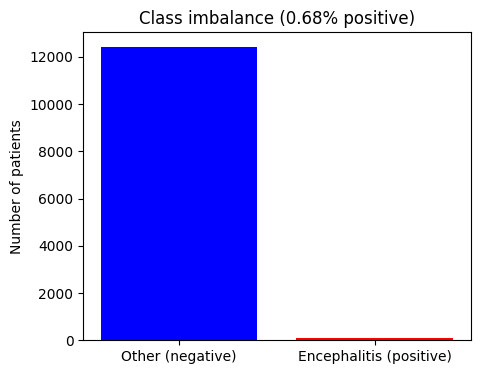

In [ ]:
counts = auto_immune_raw["auto_immune_enceph"].value_counts()
print(counts)
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Other (negative)", "Encephalitis (positive)"],
              counts.values, color=["blue", "red"])
ax.set_ylabel("Number of patients")
ax.set_title(f"Class imbalance ({100*auto_immune_raw['auto_immune_enceph'].mean():.2f}% positive)")
plt.show()

#### Counting Nulls

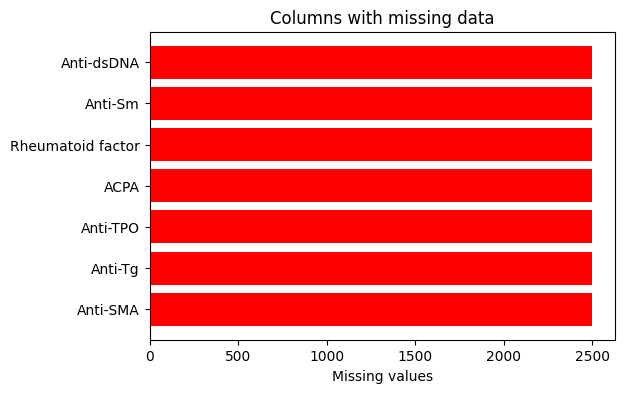

In [ ]:
nulls = auto_immune_raw.isnull().sum()
nulls = nulls[nulls>0].sort_values()

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(nulls.index[::-1], nulls.values[::-1], color="red")
ax.set_xlabel("Missing values")
ax.set_title("Columns with missing data")
plt.show()

#### Assign X, Y and split the data in train and test set

In [ ]:
X = auto_immune_raw.drop(columns=["auto_immune_enceph"])
y = auto_immune_raw["auto_immune_enceph"]

#obtain the numeric columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
#obtain non-numeri columns
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, 
                                                    test_size = 0.20, 
                                                    random_state = RANDOM_SEED)

#### Define Preprocessing Pipelines for numeric / non-numeric features

In [ ]:

# NOTE on missingness:
# Many nulls here are likely "informative": a healthy patient is never tested,
# so the value is missing *because* they are healthy. Median/most-frequent
# imputation would erase that signal. We do two things instead:
#   1. Numeric: median-impute BUT add a binary "was_missing" indicator column
#      (add_indicator=True) so the model can learn from the missingness pattern.
#   2. Categorical: fill NaN with the literal string "Missing" so it becomes
#      its own category in the one-hot encoding, instead of being merged with
#      the most common value.
numeric = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale",  StandardScaler()),
])

categorical = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))
])

preprocessor = ColumnTransformer([
    ("num", numeric, num_cols),
    ("cat", categorical, cat_cols),
])


#### Train all models

In [ ]:
spw = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced",
        n_jobs=-1, random_state=RANDOM_SEED),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=4,
        scale_pos_weight=spw, eval_metric="logloss",
        n_jobs=-1, random_state=RANDOM_SEED),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
results = {}
for name, model in models.items():
    pipe = Pipeline([("pre", preprocessor), ("clf", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring="roc_auc", n_jobs=-1)
    results[name] = scores
    print(f"{name:22s} AUC = {scores.mean():.2f}")

best = max(results, key=lambda k: results[k].mean())
print(f"\nBest model: {best}")

Logistic Regression    AUC = 0.72


KeyboardInterrupt: 

ROC-AUC in the testset: 0.710

              precision    recall  f1-score   support

       Otros      0.995     0.696     0.819      2483
 Encefalitis      0.012     0.529     0.023        17

    accuracy                          0.694      2500
   macro avg      0.504     0.612     0.421      2500
weighted avg      0.989     0.694     0.813      2500



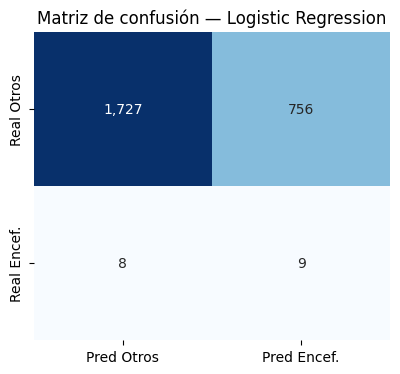

In [ ]:
best_pipe = Pipeline([("pre", preprocessor), ("clf", models[best])])
best_pipe.fit(X_train, y_train)

proba = best_pipe.predict_proba(X_test)[:, 1]   # probability of encephalitis
pred  = (proba >= 0.5).astype(int)               

print(f"ROC-AUC in the testset: {roc_auc_score(y_test, proba):.3f}\n")
print(classification_report(y_test, pred, target_names=["Otros", "Encefalitis"], digits=3))

# Matriz de confusión
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Pred Otros", "Pred Encef."],
            yticklabels=["Real Otros", "Real Encef."])
ax.set_title(f"Matriz de confusión — {best}")
plt.show()

#### Feature Importance

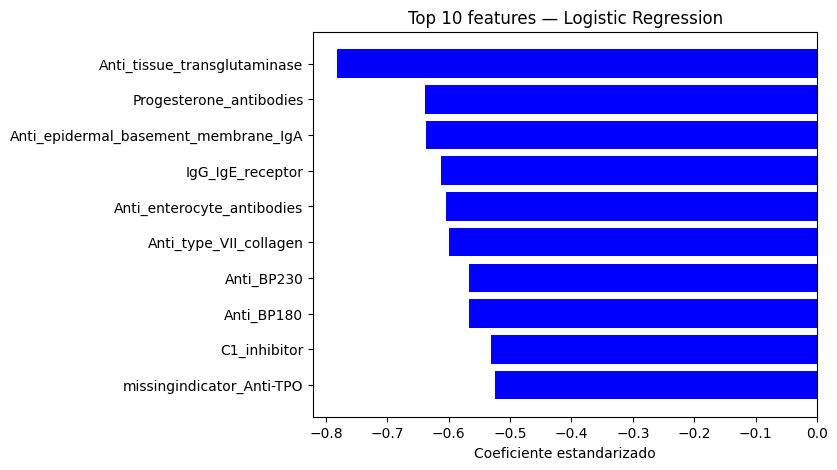

In [ ]:
feat_names = best_pipe.named_steps["pre"].get_feature_names_out()
feat_names = [n.replace("num__", "").replace("cat__", "") for n in feat_names]

clf = best_pipe.named_steps["clf"]
if hasattr(clf, "coef_"):
    vals = clf.coef_.ravel()
    etiqueta = "Coeficiente estandarizado"
else:
    vals = clf.feature_importances_
    etiqueta = "Importancia (árboles)"

imp = pd.Series(vals, index=feat_names)
top = imp.reindex(imp.abs().sort_values(ascending=False).index).head(10)[::-1]

fig, ax = plt.subplots(figsize=(6.5, 5))
colors = ["red" if v > 0 else "blue" for v in top.values]
ax.barh(top.index, top.values, color=colors)
ax.set_xlabel(etiqueta)
ax.set_title(f"Top 10 features — {best}")
plt.show()

#### Top 10 Influential Features on Autoimmune Encephalitis

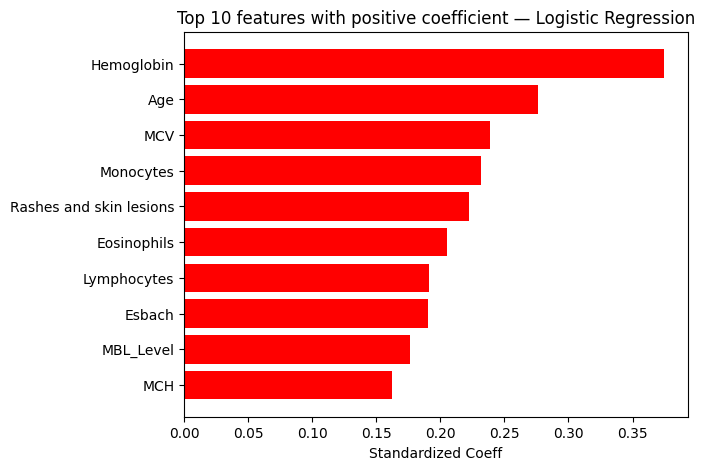

In [ ]:
top_pos = imp.sort_values(ascending=False).head(10)[::-1]

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.barh(top_pos.index, top_pos.values, color="red")
ax.set_xlabel("Standardized Coeff")
ax.set_title("Top 10 features with positive coefficient — Logistic Regression")
plt.show()

#### Precision - Recall Curve

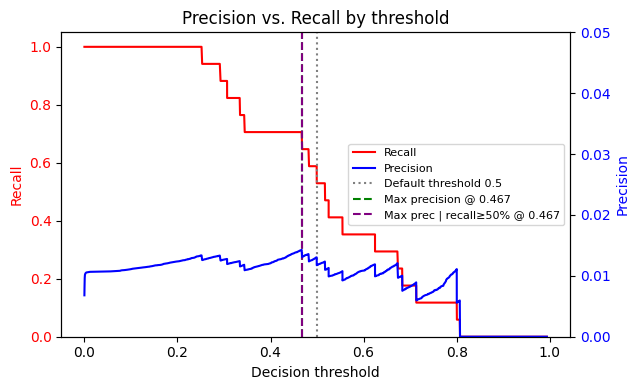

Global max precision: 0.014 at threshold 0.467 (recall there = 0.706)
Max precision with recall >= 50%: 0.014 at threshold 0.467 (recall = 0.706)
For recall >= 80%: threshold ~0.334 (precision there ~0.012)


In [ ]:

prec, rec, thr = precision_recall_curve(y_test, proba)

# --- Threshold that MAXIMIZES precision -----------------------------------
i_max = int(np.argmax(prec[:-1]))
thr_max_prec  = thr[i_max]
prec_max      = prec[i_max]
rec_at_max    = rec[i_max]

min_recall = 0.50
mask = rec[:-1] >= min_recall
if mask.any():
    j = int(np.argmax(np.where(mask, prec[:-1], -np.inf)))
    thr_best_cons  = thr[j]
    prec_best_cons = prec[j]
    rec_best_cons  = rec[j]
else:
    thr_best_cons = prec_best_cons = rec_best_cons = None
# -------------------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(6.5, 4))

# Left axis: Recall
color_rec = "red"
l1, = ax1.plot(thr, rec[:-1], label="Recall", color=color_rec)
ax1.set_xlabel("Decision threshold")
ax1.set_ylabel("Recall", color=color_rec)
ax1.tick_params(axis="y", labelcolor=color_rec)
ax1.set_ylim(0, 1.05)

# Right axis: Precision — fixed range so the plot is readable
ax2 = ax1.twinx()
color_prec = "blue"
l2, = ax2.plot(thr, prec[:-1], label="Precision", color=color_prec)
ax2.set_ylabel("Precision", color=color_prec)
ax2.tick_params(axis="y", labelcolor=color_prec)
ax2.set_ylim(0.0, 0.05)

# Reference threshold lines
v0 = ax1.axvline(0.5, ls=":", color="gray", label="Default threshold 0.5")
v1 = ax1.axvline(thr_max_prec, ls="--", color="green",
                 label=f"Max precision @ {thr_max_prec:.3f}")
handles = [l1, l2, v0, v1]
if thr_best_cons is not None:
    v2 = ax1.axvline(thr_best_cons, ls="--", color="purple",
                     label=f"Max prec | recall≥{min_recall:.0%} @ {thr_best_cons:.3f}")
    handles.append(v2)

ax1.set_title("Precision vs. Recall by threshold")
ax1.legend(handles=handles, fontsize=8, loc="center right")
plt.tight_layout()
plt.show()

print(f"Global max precision: {prec_max:.3f} at threshold {thr_max_prec:.3f} "
      f"(recall there = {rec_at_max:.3f})")

if thr_best_cons is not None:
    print(f"Max precision with recall >= {min_recall:.0%}: "
          f"{prec_best_cons:.3f} at threshold {thr_best_cons:.3f} "
          f"(recall = {rec_best_cons:.3f})")

target_recall = 0.80
ok = np.where(rec[:-1] >= target_recall)[0]
if len(ok):
    i = ok[-1]
    print(f"For recall >= {target_recall:.0%}: threshold ~{thr[i]:.3f} "
          f"(precision there ~{prec[i]:.3f})")


#### Hyperparameter Tuning with Optuna

To find the optimal hyperparameters for our models, we will use **Optuna**. We will create a separate optimization study for each of our three algorithms (Logistic Regression, Random Forest, and XGBoost), tune them using 5-fold stratified cross-validation on the training set, and then evaluate the best model of each algorithm on the test set.

##### 1. Logistic Regression Tuning using Optuna

Tuning Logistic Regression with Optuna...


C:\Users\i34005\AppData\Local\Temp\ipykernel_16532\3359934525.py:21: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(multivariate=True, seed=RANDOM_SEED)


Best Logistic Regression parameters: {'C': 889.487562807564, 'penalty': 'l1'}
Best CV ROC-AUC (3-fold): 0.712


\\wsl.localhost\Ubuntu\home\i34005\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
\\wsl.localhost\Ubuntu\home\i34005\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



Evaluating Tuned Logistic Regression on test set:
Tuned Test ROC-AUC: 0.711

              precision    recall  f1-score   support

       Otros      0.995     0.696     0.819      2483
 Encefalitis      0.012     0.529     0.023        17

    accuracy                          0.695      2500
   macro avg      0.504     0.613     0.421      2500
weighted avg      0.989     0.695     0.814      2500



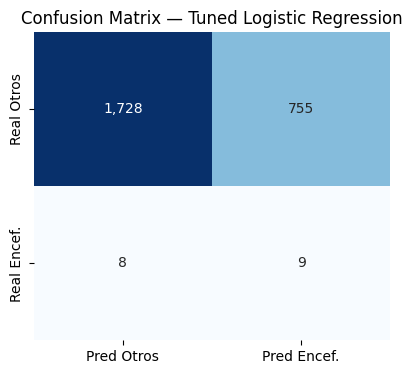

In [ ]:

# Install optuna if not already installed
# %pip install optuna -q

import optuna
from joblib import Memory
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Speed-ups -----------------------------------------------------------
# 1) Cache preprocessing across trials. The preprocessor doesn't depend on
#    trial hyperparameters, so after the first trial each fold's transformed
#    matrix is reused from disk -- only LogisticRegression is refit.
memory = Memory(location="./.sk_cache", verbose=0)

# 2) Use 3-fold CV during the *search* (cheaper). We still report a clean
#    test-set score at the end using the 20% hold-out.
cv_search = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

# 3) Multivariate TPE converges in fewer trials than the default sampler.
sampler = optuna.samplers.TPESampler(multivariate=True, seed=RANDOM_SEED)
# -------------------------------------------------------------------------

def objective_lr(trial):
    params = {
        "C": trial.suggest_float("C", 1e-3, 1e3, log=True),
        "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
        "solver": "liblinear",
        "max_iter": 2000,
        "class_weight": "balanced",
        "random_state": RANDOM_SEED,
    }

    pipe = Pipeline(
        [("pre", preprocessor), ("clf", LogisticRegression(**params))],
        memory=memory,          # <-- key speed-up
    )

    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv_search, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

print("Tuning Logistic Regression with Optuna...")
study_lr = optuna.create_study(direction="maximize", sampler=sampler)
study_lr.optimize(objective_lr, n_trials=20, show_progress_bar=False)

print(f"Best Logistic Regression parameters: {study_lr.best_params}")
print(f"Best CV ROC-AUC (3-fold): {study_lr.best_value:.3f}")

# Refit the best LR once on the full training set
best_lr_params = {
    **study_lr.best_params,
    "solver": "liblinear",
    "max_iter": 2000,
    "class_weight": "balanced",
    "random_state": RANDOM_SEED,
}

best_lr_pipe = Pipeline(
    [("pre", preprocessor), ("clf", LogisticRegression(**best_lr_params))],
    memory=memory,
)
best_lr_pipe.fit(X_train, y_train)

proba_lr = best_lr_pipe.predict_proba(X_test)[:, 1]
pred_lr = (proba_lr >= 0.5).astype(int)

print(f"\nEvaluating Tuned Logistic Regression on test set:")
print(f"Tuned Test ROC-AUC: {roc_auc_score(y_test, proba_lr):.3f}\n")
print(classification_report(y_test, pred_lr, target_names=["Otros", "Encefalitis"], digits=3))

# Confusion matrix
cm_lr = confusion_matrix(y_test, pred_lr)
fig, ax = plt.subplots(figsize=(4.6, 4))
sns.heatmap(cm_lr, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Pred Otros", "Pred Encef."],
            yticklabels=["Real Otros", "Real Encef."])
ax.set_title("Confusion Matrix — Tuned Logistic Regression")
plt.show()


#### Precision-Recall Balance

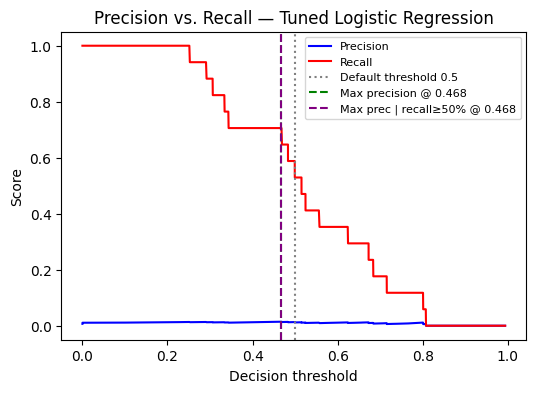

[Tuned LR] Global max precision: 0.014 at threshold 0.468 (recall there = 0.706)
[Tuned LR] Max precision with recall >= 50%: 0.014 at threshold 0.468 (recall = 0.706)


In [ ]:

# Precision–Recall analysis on the TUNED Logistic Regression model
prec_t, rec_t, thr_t = precision_recall_curve(y_test, proba_lr)

i_max = int(np.argmax(prec_t[:-1]))
thr_max_prec_t = thr_t[i_max]
prec_max_t     = prec_t[i_max]
rec_at_max_t   = rec_t[i_max]

min_recall = 0.50
mask = rec_t[:-1] >= min_recall
if mask.any():
    j = int(np.argmax(np.where(mask, prec_t[:-1], -np.inf)))
    thr_best_cons_t  = thr_t[j]
    prec_best_cons_t = prec_t[j]
    rec_best_cons_t  = rec_t[j]
else:
    thr_best_cons_t = prec_best_cons_t = rec_best_cons_t = None

fig, ax1 = plt.subplots(figsize=(6.5, 4))

# Left axis: Recall
color_rec = "red"
l1, = ax1.plot(thr_t, rec_t[:-1], label="Recall", color=color_rec)
ax1.set_xlabel("Decision threshold")
ax1.set_ylabel("Recall", color=color_rec)
ax1.tick_params(axis="y", labelcolor=color_rec)
ax1.set_ylim(0, 1.05)

# Right axis: Precision — fixed range
ax2 = ax1.twinx()
color_prec = "blue"
l2, = ax2.plot(thr_t, prec_t[:-1], label="Precision", color=color_prec)
ax2.set_ylabel("Precision", color=color_prec)
ax2.tick_params(axis="y", labelcolor=color_prec)
ax2.set_ylim(0.0, 0.05)

v0 = ax1.axvline(0.5, ls=":", color="gray", label="Default threshold 0.5")
v1 = ax1.axvline(thr_max_prec_t, ls="--", color="green",
                 label=f"Max precision @ {thr_max_prec_t:.3f}")
handles = [l1, l2, v0, v1]
if thr_best_cons_t is not None:
    v2 = ax1.axvline(thr_best_cons_t, ls="--", color="purple",
                     label=f"Max prec | recall≥{min_recall:.0%} @ {thr_best_cons_t:.3f}")
    handles.append(v2)

ax1.set_title("Precision vs. Recall — Tuned Logistic Regression")
ax1.legend(handles=handles, fontsize=8, loc="center right")
plt.tight_layout()
plt.show()

print(f"[Tuned LR] Global max precision: {prec_max_t:.3f} "
      f"at threshold {thr_max_prec_t:.3f} (recall there = {rec_at_max_t:.3f})")

if thr_best_cons_t is not None:
    print(f"[Tuned LR] Max precision with recall >= {min_recall:.0%}: "
          f"{prec_best_cons_t:.3f} at threshold {thr_best_cons_t:.3f} "
          f"(recall = {rec_best_cons_t:.3f})")
